In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [2]:
condition = "base_model_0"
checkpoint_epoch = 0
n_samples_test = 1000
split = "test"

with total_silence():

    r = []
    epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]
    n_per_cat = [ 2, 3, 4, 5, 10, 50, 100]

    for i in n_per_cat:
        global_workspace, domain_mods, gw_mod, visual_module, \
            original_data, latent_domains, modules_name = \
            get_modules_data_from_exp(
                experiment_name=condition,
                n_samples_test=n_samples_test,
                split=split,
                checkpoint_epoch=checkpoint_epoch,
            )
        
        if 'attr' in modules_name:
            cat = original_data['attr'][0]
        if 'cat' in modules_name:
            cat = original_data['cat']


        objects = get_objects_from_v_latents(
            latent_domains, gw_mod, global_workspace, modules_name, start_v=False, 
        )

        res = evaluate_robust_transfer(objects, cat, n_per_cat=i, n_iterations=50)
        r.append({i: res})

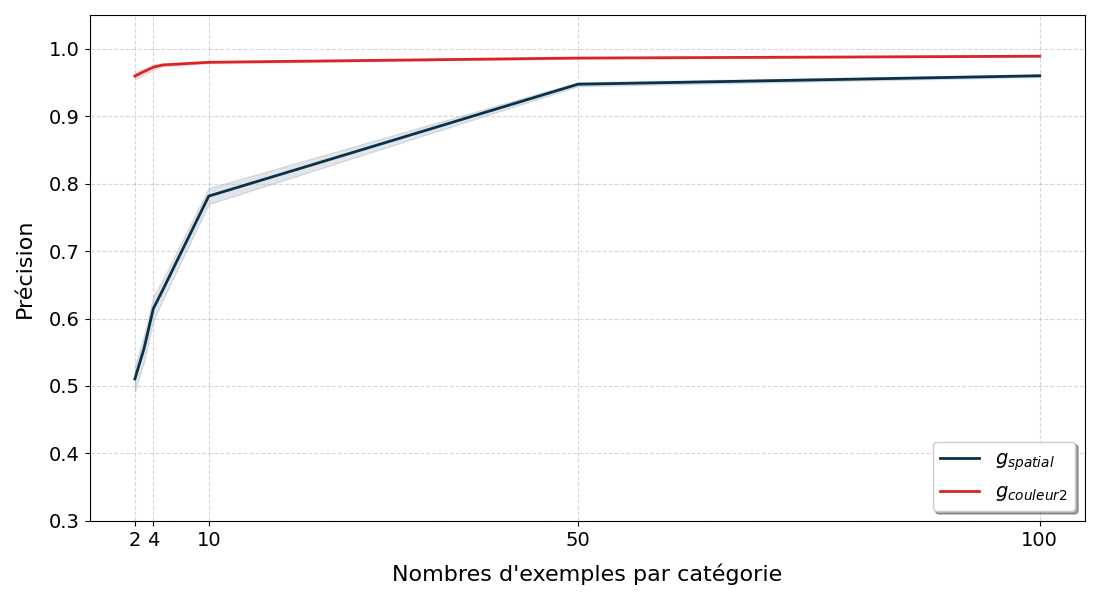

In [10]:
lang = 'fr'
DISPLAY_CONFIG = {
    'z_spatial': True,
    'z_couleur': False,
    'z_vision_2': False,
    'z_syn': True,
    'z_syn_fusion': False,
}

history = r[0:30]

keys = sorted([list(epoch_dict.keys())[0] for epoch_dict in history])

label_x = "Number of examples per category"
label_y = 'Accuracy'
label_gcol = r'$g_{color2}$'
if lang == 'fr':
    label_x = "Nombres d'exemples par catégorie"
    label_y = 'Précision'
    label_gcol = r'$g_{couleur2}$'


style_config = {
    'z_spatial': {'color': '#0a304a', 'label': r'$g_{spatial}$'},
    'z_couleur': {'color': '#39803f', 'label': 'Gw couleur'},
    'z_vision_2': {'color': '#1f77b4', 'label': 'Z'},
    'z_syn': {'color': '#d62728', 'label': label_gcol},
    'z_syn_fusion': {'color': '#d62728', 'label': 'Z_syn'}
}

plt.figure(figsize=(11, 6))
for key, should_display in DISPLAY_CONFIG.items():
    if should_display:
        means = []
        cis = []
        for epoch_dict in history:
            epoch_num = list(epoch_dict.keys())[0]
            data = epoch_dict[epoch_num][key]
            means.append(data['mean'])
            cis.append(data['ci_95'])
        means = np.array(means)
        cis = np.array(cis)

        color = style_config[key]['color']
        custom_label = style_config[key]['label']

        plt.plot(keys, means, label=custom_label,
                 color=color, linewidth=2, markersize=6)
        plt.fill_between(keys, means - cis, means + cis,
                         color=color, alpha=0.12)



plt.xlabel(label_x, fontsize=16, labelpad=10)
plt.ylabel(label_y, fontsize=16, labelpad=10)

ax = plt.gca()
ax.tick_params(axis='both', labelsize=14)
plt.xticks([2, 4, 10, 50, 100])                   # ← une valeur de tick par entrée dans keys
plt.ylim(0.3, 1.05)                   # ← 5% de marge au-dessus de 1

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
history

[{2: {'z_spatial': {'mean': 0.5104024144869215,
    'std': 0.06779567820037208,
    'ci_95': 0.018792003245924643},
   'z_couleur': {'mean': 0.332635814889336,
    'std': 0.012023307149903366,
    'ci_95': 0.0033326907110502652},
   'z_vision_2': {'mean': 0.48995975855130797,
    'std': 0.05495260091927401,
    'ci_95': 0.015232083847511848},
   'z_syn': {'mean': 0.95943661971831,
    'std': 0.019438577536981846,
    'ci_95': 0.0053880987972639805},
   'z_syn_fusion': {'mean': 0.8224144869215292,
    'std': 0.07160695270788282,
    'ci_95': 0.019848434641220554}}},
 {3: {'z_spatial': {'mean': 0.5558425832492432,
    'std': 0.06934597639326331,
    'ci_95': 0.019221723981026062},
   'z_couleur': {'mean': 0.33362260343087796,
    'std': 0.015597270334640622,
    'ci_95': 0.004323342763676669},
   'z_vision_2': {'mean': 0.5471241170534813,
    'std': 0.05976831241294829,
    'ci_95': 0.01656693097085056},
   'z_syn': {'mean': 0.9662563067608475,
    'std': 0.016079786322758048,
    'ci_95